# DATA-445 In-Class Assignment 2

Consider the `Real_Estate.csv` data file posted on Blackboard (under the In-Class 2 assignment link). This file contains information related to 414 houses. The goal is to predict the house price of unit area.

## 1. (3 points) Using the pandas library, read the csv data file and create a data-frame called `house_price`.

In [1]:
import pandas as pd

house_price = pd.read_csv('Real_Estate.csv')
house_price.head()

,No,transaction_date,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## 2. (3 points) Drop the `No` column.

In [2]:
house_price = house_price.drop(columns=['No'])
house_price.head()

,transaction_date,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## 3. (4 points) Create a scatter plot of `house_age` and `house_price_of_unit_area`. Describe the plot.

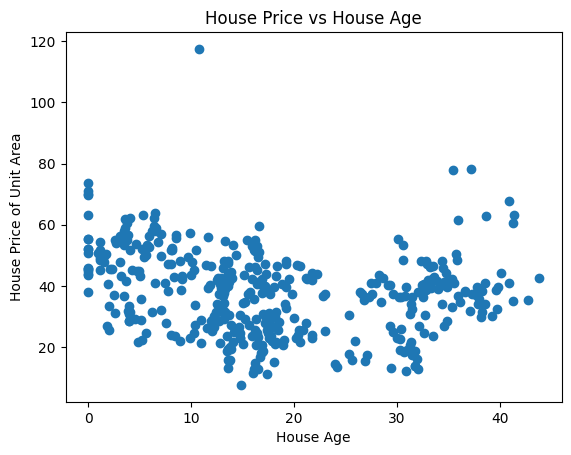

In [3]:
import matplotlib.pyplot as plt

plt.plot(house_price['house_age'], house_price['house_price_of_unit_area'], 'o')
plt.xlabel('House Age')
plt.ylabel('House Price of Unit Area')
plt.title('House Price vs House Age')
plt.show()

From the above scatter plot, we see that there are two groups of houses (newer (less than or equal to 25 years old) and older (greater than or equal to 25)). The house price unit of unit area of each of those groups behave different (probably because of location and other features associated to the houses).

## 4. (4 points) Create a scatter plot of `distance_to_the_nearest_MRT_station` and `house_price_of_unit_area`. Describe the plot.

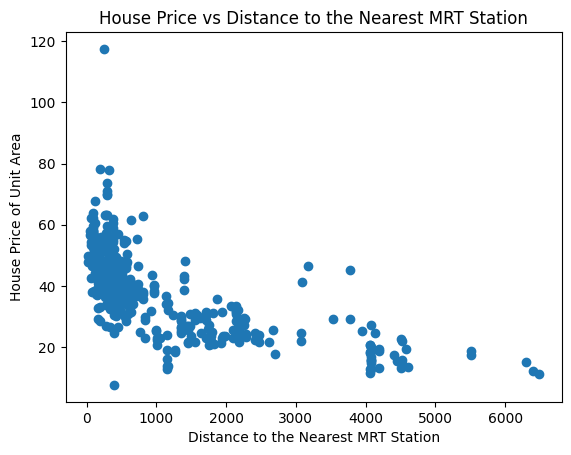

In [4]:
plt.plot(house_price['distance_to_the_nearest_MRT_station'], house_price['house_price_of_unit_area'], 'o')
plt.xlabel('Distance to the Nearest MRT Station')
plt.ylabel('House Price of Unit Area')
plt.title('House Price vs Distance to the Nearest MRT Station')
plt.show()

From the above plot, we see that the closer the house is to the MRT station, on average, the higher the house price of unit area.

## 5. (5 points) Build a linear regression model

Input variables: `house_age`, `distance_to_the_nearest_MRT_station`, `number_of_convenience_stores`, `latitude`, and `longitude`.

Target variable: `house_price_of_unit_area`.

In [5]:
from sklearn.linear_model import LinearRegression

# Defining the input and target variables
X = house_price[['house_age', 'distance_to_the_nearest_MRT_station', 'number_of_convenience_stores', 'latitude', 'longitude']]
y = house_price['house_price_of_unit_area']

# Creating the linear regression model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

## 6. (3 points) Using the model from part 5, predict the house price of unit area

For a house with: `house_age = 5`, `distance_to_the_nearest_MRT_station = 500`, `number_of_convenience_stores = 3`, `latitude = 24.98`, and `longitude = 121.49`.

In [6]:
# Defining the input for prediction
new_data = pd.DataFrame({
    'house_age': [5],
    'distance_to_the_nearest_MRT_station': [500],
    'number_of_convenience_stores': [3],
    'latitude': [24.98],
    'longitude': [121.49]
})

new_data

,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude
0,5,500,3,24.98,121.49


In [7]:
# Predicting the house price of unit area for the new data
predicted_price = model.predict(new_data)
print(f"Predicted House Price of Unit Area: {predicted_price[0]:.2f}")

Predicted House Price of Unit Area: 45.56
